# Analyse Bottleneck améliorée avec l IA

Ce notebook améliore le notebook de référence à partir des recommandations de l’assistant le mieux noté dans la comparaison, ChatGPT. Il conserve les données brutes, rend les anomalies visibles, sécurise les jointures et clarifie le sens des indicateurs.

**Principe pédagogique.** Avant chaque modification importante, un encadré explique simplement le problème observé, la correction retenue et la manière de la vérifier. Une proposition de l’IA reste une piste : les règles métier doivent être validées par le responsable des ventes ou le propriétaire de la donnée.

In [2]:
# Téléchargement des sources depuis GitHub vers le dossier courant de Colab
import pandas as pd
import numpy as np

!wget -q https://raw.githubusercontent.com/Sadiestar/Business-Intelligence-et-analyse-de-donnees/main/OpenClassrooms/Projet_11/erp.xlsx
!wget -q https://raw.githubusercontent.com/Sadiestar/Business-Intelligence-et-analyse-de-donnees/main/OpenClassrooms/Projet_11/web.xlsx
!wget -q https://raw.githubusercontent.com/Sadiestar/Business-Intelligence-et-analyse-de-donnees/main/OpenClassrooms/Projet_11/liaison.xlsx

'wget' n’est pas reconnu en tant que commande interne
ou externe, un programme exécutable ou un fichier de commandes.
'wget' n’est pas reconnu en tant que commande interne
ou externe, un programme exécutable ou un fichier de commandes.
'wget' n’est pas reconnu en tant que commande interne
ou externe, un programme exécutable ou un fichier de commandes.


## 1 Contexte et hypothèses

- Les données de stock sont arrêtées au 31 octobre.
- `total_sales` est interprété comme la quantité vendue du 1er au 31 octobre.
- `price` est supposé TTC et une TVA de 20 % est utilisée pour l’analyse de marge. Cette hypothèse doit être confirmée.
- Le ratio stock sur ventes décrit une **couverture théorique au rythme d’octobre**. Il ne démontre pas une rotation historique.
- Une ligne d’analyse représente un produit ERP déclaré en ligne et rapproché d’une fiche WordPress de type `product`.

## 2 Préparer un environnement reproductible

**Pourquoi modifier ?** Les imports étaient dispersés et le notebook dépendait du dossier depuis lequel il était lancé.

**Ce qui change.** Tous les imports sont regroupés. Le code cherche les fichiers dans le dossier courant puis dans `livrables`. Les versions utilisées sont affichées.

**Vérification.** La cellule s’arrête avec un message clair si un fichier manque.

In [1]:
from pathlib import Path
import platform
import json

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

candidates = [Path.cwd(), Path.cwd() / "livrables"]
DATA_DIR = next((p for p in candidates if all((p / f).exists() for f in ["erp.xlsx", "web.xlsx", "liaison.xlsx"])), None)
if DATA_DIR is None:
    raise FileNotFoundError("Placez erp.xlsx, web.xlsx et liaison.xlsx dans le dossier courant ou dans livrables.")

OUTPUT_DIR = DATA_DIR / "outputs" / "notebook_ameliore"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

versions = {
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__,
}
print("Dossier des données :", DATA_DIR.resolve())
pd.Series(versions, name="version")

Dossier des données : C:\Users\idko7470\OneDrive - France Travail\Formations\Openclassroom\Projet_11\livrables


python        3.13.9
pandas         2.3.3
numpy          2.3.5
matplotlib    3.10.6
seaborn       0.13.2
Name: version, dtype: object

## 3 Charger les sources sans les modifier

**Pourquoi modifier ?** Le notebook initial transformait directement certains DataFrames. Il devenait difficile de distinguer la donnée reçue de la donnée corrigée.

**Ce qui change.** Les tables d’origine portent le suffixe `_raw` et ne seront jamais écrasées.

**Vérification.** Le profil affiche les dimensions et les doublons exacts de chaque source.

In [2]:
erp_raw = pd.read_excel(DATA_DIR / "erp.xlsx")
web_raw = pd.read_excel(DATA_DIR / "web.xlsx")
liaison_raw = pd.read_excel(DATA_DIR / "liaison.xlsx")

source_profile = pd.DataFrame([
    {"source": "ERP", "lignes": len(erp_raw), "colonnes": erp_raw.shape[1], "doublons_exacts": int(erp_raw.duplicated().sum())},
    {"source": "Web", "lignes": len(web_raw), "colonnes": web_raw.shape[1], "doublons_exacts": int(web_raw.duplicated().sum())},
    {"source": "Liaison", "lignes": len(liaison_raw), "colonnes": liaison_raw.shape[1], "doublons_exacts": int(liaison_raw.duplicated().sum())},
])
source_profile

C:\Users\idko7470\AppData\Local\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\idko7470\AppData\Local\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\idko7470\AppData\Local\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,source,lignes,colonnes,doublons_exacts
0,ERP,825,6,0
1,Web,1513,29,82
2,Liaison,825,2,0


## 4 Remplacer les corrections silencieuses par un rapport qualité

**Pourquoi modifier ?** Transformer un prix négatif avec `abs()`, ramener un stock négatif à zéro ou effacer les prix du produit 4355 peut fabriquer une valeur sans validation métier.

**Ce qui change.** Le notebook signale les anomalies, conserve les valeurs originales et indique l’action attendue.

**Vérification.** Le rapport donne le nombre et le taux de lignes concernées par chaque règle.

In [3]:
quality_checks = []
def add_check(source, control, mask, severity, action):
    affected = int(mask.fillna(False).sum())
    quality_checks.append({
        "source": source, "controle": control, "lignes_affectees": affected,
        "taux": affected / len(mask) if len(mask) else np.nan,
        "severite": severity, "action": action,
    })

add_check("ERP", "product_id duplique", erp_raw["product_id"].duplicated(), "Critique", "Bloquer la jointure")
add_check("ERP", "prix <= 0", erp_raw["price"].le(0), "Haute", "Mettre en quarantaine et valider")
add_check("ERP", "stock negatif", erp_raw["stock_quantity"].lt(0), "Haute", "Conserver la valeur et corriger la source")
status_calc_raw = pd.Series(np.where(erp_raw["stock_quantity"].gt(0), "instock", "outofstock"), index=erp_raw.index)
add_check("ERP", "statut different du statut calcule", erp_raw["stock_status"].ne(status_calc_raw), "Haute", "Faire valider la source de verite")
add_check("Web", "SKU manquant", web_raw["sku"].isna(), "Haute", "Exclure du rapprochement")
add_check("Web", "ligne hors grain product", web_raw["post_type"].ne("product"), "Critique", "Filtrer avant la jointure")
add_check("Web", "vente negative", web_raw["total_sales"].lt(0), "Haute", "Mettre en quarantaine")
add_check("Liaison", "id_web manquant", liaison_raw["id_web"].isna(), "Haute", "Completer la liaison")
add_check("Liaison", "product_id duplique", liaison_raw["product_id"].duplicated(), "Critique", "Bloquer la jointure")

quality_report = pd.DataFrame(quality_checks)
quality_report.style.format({"taux": "{:.1%}"})

,source,controle,lignes_affectees,taux,severite,action
0,ERP,product_id duplique,0,0.0%,Critique,Bloquer la jointure
1,ERP,prix <= 0,3,0.4%,Haute,Mettre en quarantaine et valider
2,ERP,stock negatif,2,0.2%,Haute,Conserver la valeur et corriger la source
3,ERP,statut different du statut calcule,2,0.2%,Haute,Faire valider la source de verite
4,Web,SKU manquant,85,5.6%,Haute,Exclure du rapprochement
5,Web,ligne hors grain product,797,52.7%,Critique,Filtrer avant la jointure
6,Web,vente negative,2,0.1%,Haute,Mettre en quarantaine
7,Liaison,id_web manquant,91,11.0%,Haute,Completer la liaison
8,Liaison,product_id duplique,0,0.0%,Critique,Bloquer la jointure


## 5 Normaliser les clés et sécuriser les jointures

**Pourquoi modifier ?** Une jointure sans contrôle peut multiplier les lignes et gonfler silencieusement le chiffre d’affaires, le stock ou les ventes.

**Ce qui change.** Les clés sont normalisées sans supprimer arbitrairement les identifiants textuels. L'unicité est contrôlée uniquement sur les clés renseignées ; les produits sans clé restent visibles dans le bilan. `validate` contrôle la cardinalité et `indicator` montre les correspondances.

**Vérification.** Les assertions bloquent l’exécution si une clé attendue unique est dupliquée.

In [4]:
def normalize_key(series):
    cleaned = series.astype("string").str.strip()
    numeric = pd.to_numeric(cleaned, errors="coerce")
    integer_mask = numeric.notna() & numeric.mod(1).eq(0)
    cleaned.loc[integer_mask] = numeric.loc[integer_mask].astype("Int64").astype("string")
    return cleaned

erp_online = erp_raw.loc[erp_raw["onsale_web"].eq(1)].copy()
liaison = liaison_raw.copy()
web_products = web_raw.loc[web_raw["post_type"].eq("product") & web_raw["sku"].notna()].copy()
liaison["sku_key"] = normalize_key(liaison["id_web"])
web_products["sku_key"] = normalize_key(web_products["sku"])

assert erp_online["product_id"].is_unique, "product_id doit être unique dans ERP."
assert liaison["product_id"].is_unique, "product_id doit être unique dans la liaison."
assert web_products["sku_key"].is_unique, "sku_key doit être unique parmi les fiches produit."

erp_liaison = erp_online.merge(
    liaison[["product_id", "sku_key"]], on="product_id", how="left",
    validate="one_to_one", indicator="liaison_match"
)
assert erp_liaison.loc[erp_liaison["sku_key"].notna(), "sku_key"].is_unique, (
    "Les cles Web renseignees doivent etre uniques cote ERP-liaison."
)
analysis = erp_liaison.merge(
    web_products[["sku_key", "total_sales", "product_type", "post_title"]],
    on="sku_key", how="left", validate="many_to_one", indicator="web_match"
)

join_summary = pd.DataFrame([
    ["Produits ERP declares en ligne", len(erp_online)],
    ["Produits avec cle de liaison", int(analysis["sku_key"].notna().sum())],
    ["Produits retrouves dans le Web", int(analysis["web_match"].eq("both").sum())],
    ["Produits ERP sans cle de liaison", int(analysis["sku_key"].isna().sum())],
    ["Produits lies sans fiche Web", int(analysis["sku_key"].notna().sum() - analysis["web_match"].eq("both").sum())],
], columns=["indicateur", "valeur"])
join_summary

,indicateur,valeur
0,Produits ERP declares en ligne,716
1,Produits avec cle de liaison,713
2,Produits retrouves dans le Web,713
3,Produits ERP sans cle de liaison,3
4,Produits lies sans fiche Web,0


## 6 Créer des variables d’analyse sans effet de bord

**Pourquoi modifier ?** Les affectations `df_z = df_final` et `df_ca = df_final` faisaient pointer plusieurs noms vers le même objet. Ajouter une colonne à l’un modifiait les autres.

**Ce qui change.** Une seule table `analysis` reçoit explicitement les variables calculées. Les valeurs invalides sont neutralisées uniquement pour le calcul concerné.

**Vérification.** Les colonnes `flag_...` permettent de retrouver chaque ligne exclue d’un indicateur.

In [5]:
analysis["stock_status_calc"] = np.where(analysis["stock_quantity"].gt(0), "instock", "outofstock")
analysis["flag_stock_negative"] = analysis["stock_quantity"].lt(0)
analysis["flag_stock_status"] = analysis["stock_status"].ne(analysis["stock_status_calc"])
analysis["flag_price_invalid"] = analysis["price"].le(0)
analysis["price_valid"] = analysis["price"].where(~analysis["flag_price_invalid"])
analysis["price_ex_vat"] = analysis["price_valid"] / 1.20
analysis["flag_margin_invalid"] = analysis["price_ex_vat"].le(analysis["purchase_price"])
analysis["stock_valid"] = analysis["stock_quantity"].where(~analysis["flag_stock_negative"])
analysis["revenue"] = analysis["price_valid"] * analysis["total_sales"]
analysis["unit_margin"] = (analysis["price_ex_vat"] - analysis["purchase_price"]).where(~analysis["flag_margin_invalid"])
analysis["margin_rate"] = analysis["unit_margin"] / analysis["purchase_price"]
analysis["stock_value"] = analysis["stock_valid"] * analysis["purchase_price"]
analysis["stock_cover_months"] = np.where(
    analysis["total_sales"].gt(0), analysis["stock_valid"] / analysis["total_sales"], np.nan
)

analysis[["product_id", "post_title", "price", "price_ex_vat", "flag_price_invalid", "flag_margin_invalid"]].head()

,product_id,post_title,price,price_ex_vat,flag_price_invalid,flag_margin_invalid
0,3847,Pierre Jean Villa Saint-Joseph Préface 2018,24.20,20.17,False,False
1,3849,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,34.30,28.58,False,False
2,3850,Pierre Jean Villa Crozes-Hermitage Accroche Co...,20.80,17.33,False,False
3,4032,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,14.10,11.75,False,False
4,4039,Pierre Jean Villa Côte Rôtie Carmina 2017,46.00,38.33,False,False


## 7 Calculer des KPI avec leur définition

**Pourquoi modifier ?** Un total peut paraître fiable alors que certaines lignes sont absentes du calcul.

**Ce qui change.** Chaque KPI indique son unité, sa définition et sa couverture.

**Vérification.** Les taux de couverture montrent la part des lignes réellement utilisées.

In [6]:
matched = analysis["web_match"].eq("both")
analysis_matched = analysis.loc[matched].copy()

kpis = pd.DataFrame([
    ["Produits apparies", len(analysis_matched), "produits", "Fiches ERP et Web rapprochees", matched.mean()],
    ["Chiffre d'affaires TTC", analysis_matched["revenue"].sum(), "EUR", "Prix TTC valide x quantite vendue", analysis_matched["revenue"].notna().mean()],
    ["Quantites vendues", analysis_matched["total_sales"].sum(), "unites", "Somme de total_sales", analysis_matched["total_sales"].notna().mean()],
    ["Stock disponible", analysis_matched["stock_valid"].sum(), "unites", "Stock non negatif", analysis_matched["stock_valid"].notna().mean()],
    ["Valeur du stock", analysis_matched["stock_value"].sum(), "EUR", "Stock valide x prix d'achat", analysis_matched["stock_value"].notna().mean()],
    ["Marge brute estimee", (analysis_matched["unit_margin"] * analysis_matched["total_sales"]).sum(), "EUR", "Marge unitaire valide x ventes", analysis_matched["unit_margin"].notna().mean()],
], columns=["KPI", "Valeur", "Unite", "Definition", "Couverture"])
kpis.style.format({"Valeur": "{:,.2f}", "Couverture": "{:.1%}"})

,KPI,Valeur,Unite,Definition,Couverture
0,Produits apparies,713.00,produits,Fiches ERP et Web rapprochees,99.6%
1,Chiffre d'affaires TTC,"143,598.90",EUR,Prix TTC valide x quantite vendue,100.0%
2,Quantites vendues,"5,737.00",unites,Somme de total_sales,100.0%
3,Stock disponible,"16,707.00",unites,Stock non negatif,99.9%
4,Valeur du stock,"277,225.11",EUR,Stock valide x prix d'achat,99.9%
5,Marge brute estimee,"44,636.66",EUR,Marge unitaire valide x ventes,99.9%


## 8 Corriger le classement des ventes et le seuil Pareto

**Pourquoi modifier ?** Le graphique intitulé « quantités vendues » utilisait le stock. Le filtre Pareto excluait aussi le produit qui faisait franchir 80 %.

**Ce qui change.** Le classement des ventes utilise `total_sales`. Le Pareto inclut la première ligne dont le cumul atteint ou dépasse 80 %.

**Vérification.** Le cumul final de la sélection doit être supérieur ou égal à 80 %.

In [7]:
ranked = analysis_matched.sort_values("revenue", ascending=False, na_position="last").copy()
revenue_total = ranked["revenue"].sum()
ranked["revenue_share"] = ranked["revenue"] / revenue_total
ranked["revenue_share_cum"] = ranked["revenue_share"].cumsum()
crossing_position = int(np.searchsorted(ranked["revenue_share_cum"].fillna(1).to_numpy(), 0.80, side="left"))
pareto_selection = ranked.iloc[:crossing_position + 1].copy()
assert pareto_selection["revenue_share_cum"].iloc[-1] >= 0.80

top10_revenue = ranked[["post_title", "revenue", "total_sales", "stock_quantity"]].head(10)
top10_sales = analysis_matched.nlargest(10, "total_sales")[["post_title", "total_sales", "revenue", "stock_quantity"]]
print(f"{len(pareto_selection)} produits, soit {len(pareto_selection)/len(ranked):.1%} du catalogue, permettent d'atteindre au moins 80 % du CA.")
top10_sales

434 produits, soit 60.9% du catalogue, permettent d'atteindre au moins 80 % du CA.


,post_title,total_sales,revenue,stock_quantity
365,Château De La Selve IGP Coteaux de l'Ardèche M...,36.00,356.40,121
121,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,27.00,267.30,74
174,I Fabbri Chianti Classico Lamole 2017,24.00,357.60,62
265,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22.00,627.00,45
321,François Baur Pinot Noir Schlittweg 2017,22.00,279.40,0
584,Agnès Levet Côte Rôtie Améthyste 2017,20.00,824.00,34
647,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,20.00,104.00,68
134,Xavier Frissant Touraine Amboise Chenin Les Pi...,18.00,208.80,48
563,Maurel Pays d'Oc Merlot 2018,17.00,98.60,44
572,Château Tour Haut-Caussan Médoc 2015,17.00,290.70,47


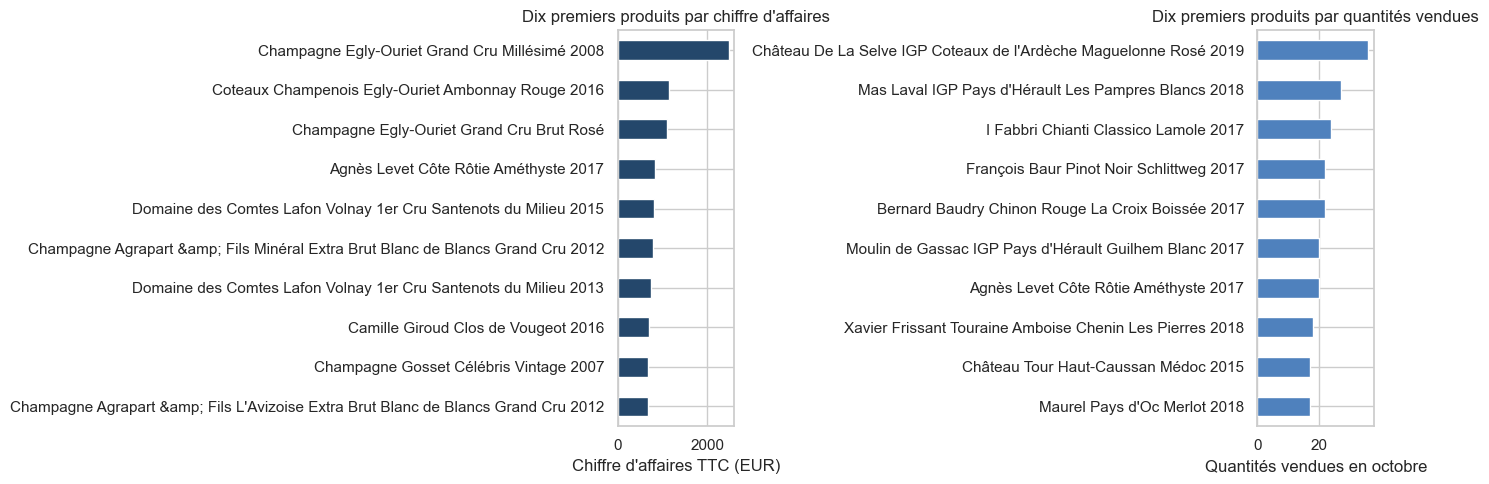

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top10_revenue.sort_values("revenue").plot.barh(x="post_title", y="revenue", ax=axes[0], legend=False, color="#24476B")
axes[0].set(title="Dix premiers produits par chiffre d'affaires", xlabel="Chiffre d'affaires TTC (EUR)", ylabel="")
top10_sales.sort_values("total_sales").plot.barh(x="post_title", y="total_sales", ax=axes[1], legend=False, color="#4F81BD")
axes[1].set(title="Dix premiers produits par quantités vendues", xlabel="Quantités vendues en octobre", ylabel="")
plt.tight_layout()
plt.show()

## 9 Comparer IQR et Z score sans déclarer automatiquement une erreur

**Pourquoi modifier ?** Un prix élevé peut être normal pour un produit haut de gamme. Le Z score est également sensible à une distribution asymétrique.

**Ce qui change.** L’IQR sert d’alerte principale et le Z score de comparaison. Aucun prix n’est corrigé automatiquement.

**Vérification.** Les deux nombres de produits signalés sont présentés ensemble.

In [9]:
q1, q3 = analysis_matched["price_valid"].quantile([0.25, 0.75])
iqr = q3 - q1
analysis_matched["price_outlier_iqr"] = ~analysis_matched["price_valid"].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
std = analysis_matched["price_valid"].std(ddof=0)
analysis_matched["price_zscore"] = (analysis_matched["price_valid"] - analysis_matched["price_valid"].mean()) / std
analysis_matched["price_outlier_z"] = analysis_matched["price_zscore"].abs().gt(3)

outlier_comparison = pd.DataFrame({
    "methode": ["IQR 1,5 x ecart interquartile", "Z score absolu > 3"],
    "prix_signales": [int(analysis_matched["price_outlier_iqr"].sum()), int(analysis_matched["price_outlier_z"].sum())],
})
outlier_comparison

,methode,prix_signales
0,"IQR 1,5 x ecart interquartile",31
1,Z score absolu > 3,13


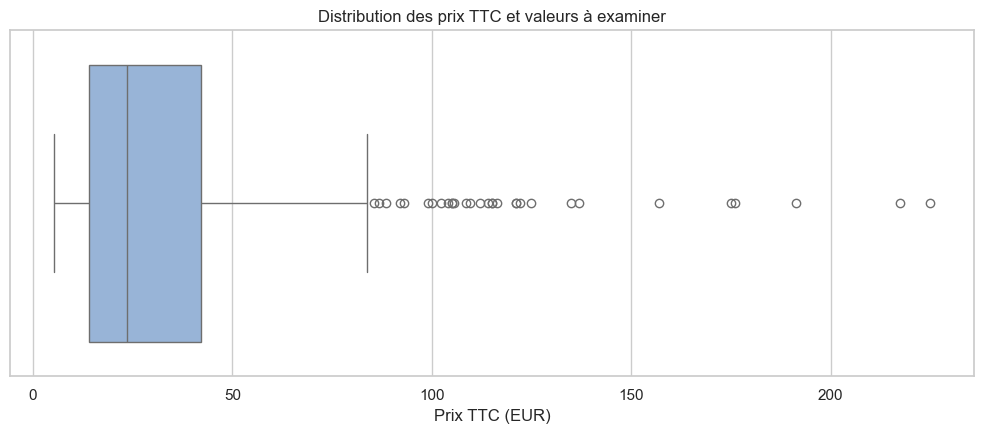

In [10]:
plt.figure(figsize=(10, 4.5))
sns.boxplot(data=analysis_matched, x="price_valid", color="#8DB3E2")
plt.title("Distribution des prix TTC et valeurs à examiner")
plt.xlabel("Prix TTC (EUR)")
plt.tight_layout()
plt.show()

## 10 Clarifier la couverture de stock et les corrélations

**Pourquoi modifier ?** `stock / ventes` n’est exprimé en mois que parce que les ventes couvrent ici octobre. Une corrélation ne prouve pas qu’une variable en cause une autre.

**Ce qui change.** Le nom `stock_cover_months` et les titres rappellent l’hypothèse temporelle. La matrice est triangulaire pour éviter les doublons visuels.

**Vérification.** Les lignes sans vente ont une couverture manquante au lieu d’une division par zéro.

In [11]:
stock_alerts = analysis_matched.loc[
    analysis_matched["stock_cover_months"].ge(12),
    ["post_title", "stock_quantity", "total_sales", "stock_cover_months"]
].sort_values("stock_cover_months", ascending=False)
print(f"Produits avec au moins 12 mois théoriques de couverture au rythme d'octobre : {len(stock_alerts)}")
stock_alerts.head(15)

Produits avec au moins 12 mois théoriques de couverture au rythme d'octobre : 25


,post_title,stock_quantity,total_sales,stock_cover_months
70,Champagne Gosset Grand Millésime 2006,125,4.00,31.25
644,Champagne Gosset Célébris Vintage 2007,138,5.00,27.60
201,Champagne Egly-Ouriet Premier Cru Les Vignes d...,81,3.00,27.00
196,Champagne Egly-Ouriet Grand Cru Brut Tradition,125,5.00,25.00
74,Champagne Mailly Grand Cru Brut Rosé,71,3.00,23.67
202,Champagne Larmandier-Bernier Latitude,115,5.00,23.00
71,Champagne Gosset Grand Rosé,91,4.00,22.75
437,Champagne Agrapart &amp; Fils L'Avizoise Extra...,136,6.00,22.67
197,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,145,7.00,20.71
76,Champagne Mailly Grand Cru Intemporelle 2010,123,6.00,20.50


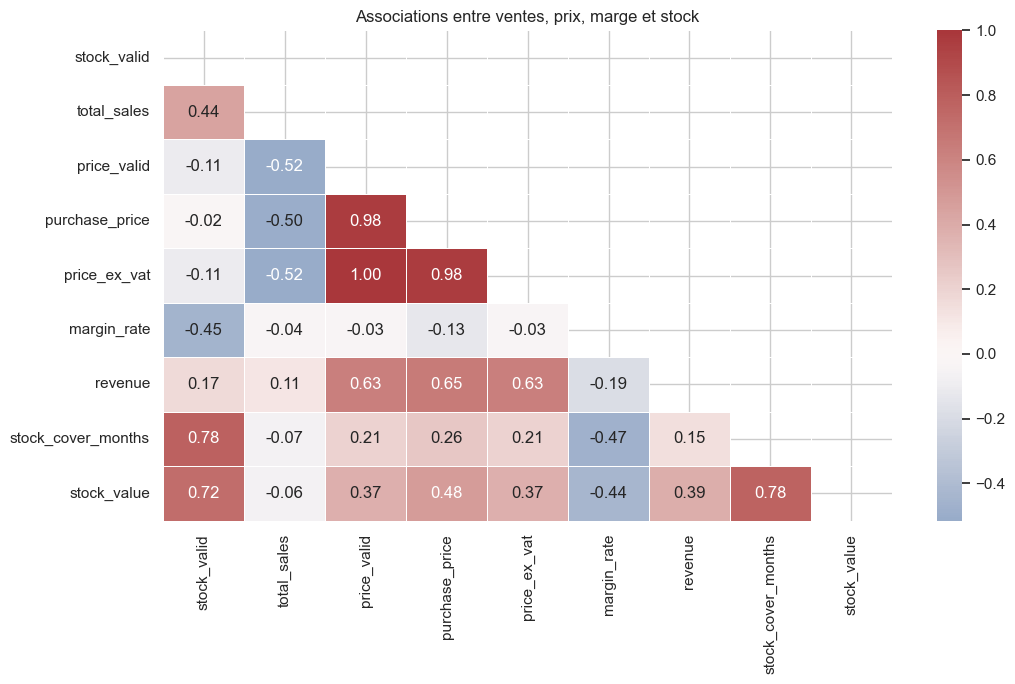

In [12]:
correlation_columns = ["stock_valid", "total_sales", "price_valid", "purchase_price", "price_ex_vat", "margin_rate", "revenue", "stock_cover_months", "stock_value"]
corr = analysis_matched[correlation_columns].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(11, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=.5)
plt.title("Associations entre ventes, prix, marge et stock")
plt.tight_layout()
plt.show()

## 11 Exporter le bon DataFrame et conserver les preuves

**Pourquoi modifier ?** Le notebook initial créait `df_analyse_final`, puis exportait un autre DataFrame. Certaines colonnes calculées pouvaient manquer.

**Ce qui change.** La table finale réellement utilisée est exportée avec le rapport qualité, les contrôles de jointure, les KPI et un résumé JSON.

**Vérification.** Le notebook relit l’export Excel et contrôle le nombre de lignes et les colonnes essentielles.

In [13]:
export_columns = [
    "product_id", "sku_key", "product_type", "post_title", "total_sales", "price", "purchase_price",
    "stock_quantity", "stock_status", "stock_status_calc", "revenue", "price_ex_vat", "unit_margin",
    "margin_rate", "stock_value", "stock_cover_months", "price_outlier_iqr", "price_outlier_z",
    "flag_stock_negative", "flag_stock_status", "flag_price_invalid", "flag_margin_invalid",
]
final_analysis = analysis_matched[export_columns].copy()
excel_path = OUTPUT_DIR / "donnees_analysees_ameliorees.xlsx"
final_analysis.to_excel(excel_path, index=False)
quality_report.to_excel(OUTPUT_DIR / "rapport_qualite.xlsx", index=False)
join_summary.to_excel(OUTPUT_DIR / "rapport_jointures.xlsx", index=False)
kpis.to_excel(OUTPUT_DIR / "kpi_bottleneck.xlsx", index=False)

summary = {
    "produits_apparies": int(len(final_analysis)),
    "chiffre_affaires_ttc": float(final_analysis["revenue"].sum()),
    "quantites_vendues": int(final_analysis["total_sales"].sum()),
    "valeur_stock": float(final_analysis["stock_value"].sum()),
    "produits_pareto_80": int(len(pareto_selection)),
    "prix_signales_iqr": int(final_analysis["price_outlier_iqr"].sum()),
    "prix_signales_zscore": int(final_analysis["price_outlier_z"].sum()),
    "versions": versions,
}
(OUTPUT_DIR / "resultats_cles.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

check = pd.read_excel(excel_path)
assert len(check) == len(final_analysis)
assert {"revenue", "margin_rate", "stock_value", "stock_cover_months"}.issubset(check.columns)
print("Exports contrôlés dans :", OUTPUT_DIR.resolve())
summary

Exports contrôlés dans : C:\Users\idko7470\OneDrive - France Travail\Formations\Openclassroom\Projet_11\livrables\outputs\notebook_ameliore


{'produits_apparies': 713,
 'chiffre_affaires_ttc': 143598.90000000002,
 'quantites_vendues': 5737,
 'valeur_stock': 277225.11,
 'produits_pareto_80': 434,
 'prix_signales_iqr': 31,
 'prix_signales_zscore': 13,
 'versions': {'python': '3.13.9',
  'pandas': '2.3.3',
  'numpy': '2.3.5',
  'matplotlib': '3.10.6',
  'seaborn': '0.13.2'}}

## 12 Conclusion pédagogique

- Les données brutes restent intactes et les anomalies sont visibles dans des indicateurs dédiés.
- Les jointures échouent explicitement si leur cardinalité n’est plus conforme.
- Le graphique des ventes utilise désormais `total_sales` et le Pareto inclut le produit qui franchit 80 %.
- La couverture de stock est reliée au seul mois d’octobre et les corrélations restent descriptives.
- Le fichier exporté correspond exactement au DataFrame final enrichi.

**Contrôles métier encore nécessaires.** Confirmer la TVA, la signification exacte de `total_sales`, la règle du statut de stock et le traitement des prix inférieurs au prix d’achat.